In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re

In [ ]:
base_dir = Path("raw_data")

# class0_ellen_1_024.npy
filename_pattern = re.compile(r"(class[01])_([a-zA-Z0-9]+)_(\d+)_(\d+)\.npy$")

def extract_metadata(filepath: Path):
    """Extracts spectrogram metadata based on the filename and its content"""
    match = filename_pattern.match(filepath.name)
    if not match:
        print("Skipped (invalid format):", filepath.name)
        return None

    class_name, speaker, recording_id, segment_id = match.groups()

    try:
        mel = np.load(filepath)
    except Exception as e:
        print("Read error:", filepath.name, e)
        return None

    if mel.ndim != 2:
        print("Invalid dimensions:", filepath.name, mel.shape)
        return None
    
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mean_intensity = float(np.mean(mel_db))

    return {
        "path": str(filepath),
        "dataset_split": filepath.parts[-3],  #train_data, test_data, validation_data
        "class_number": int(class_name[-1]),
        "class_name": class_name,
        "speaker": speaker,
        "recording_id": int(recording_id),
        "segment_id": int(segment_id),
        "n_mels": mel.shape[0],
        "n_frames": mel.shape[1],
        "mean_intensity_db": mean_intensity,
        "mean": float(np.mean(mel)),
        "std": float(np.std(mel)),
        "min": float(np.min(mel)),
        "max": float(np.max(mel)),
    }


def collect_dataset(base_path: Path):
    """Collects all spectrograms and builds a DataFrame"""
    rows = []
    for f in base_path.rglob("*.npy"):
        meta = extract_metadata(f)
        if meta:
            rows.append(meta)
    return pd.DataFrame(rows)

In [3]:
print("Loading .npy files from:", base_dir)
df_mel = collect_dataset(base_dir)
print(f"Loaded {len(df_mel)} files\n")

df_mel.head()

Loading .npy files from: raw_data
Skipped (invalid format): class1_swift_1_000(1).npy
Skipped (invalid format): class1_swift_1_001(1).npy
Skipped (invalid format): class1_swift_1_002(1).npy
Skipped (invalid format): class1_swift_1_003(1).npy
Skipped (invalid format): class1_swift_1_004(1).npy
Skipped (invalid format): class1_swift_1_005(1).npy
Skipped (invalid format): class1_swift_1_006(1).npy
Skipped (invalid format): class1_swift_1_007(1).npy
Skipped (invalid format): class1_swift_1_008(1).npy
Skipped (invalid format): class1_swift_1_009(1).npy
Skipped (invalid format): class1_trisha_1_026(1).npy
Skipped (invalid format): class1_trisha_1_030(1).npy
Skipped (invalid format): class1_trisha_1_031(1).npy
Skipped (invalid format): class1_trisha_1_032(1).npy
Skipped (invalid format): class0_blanchett_3_151(1).npy
Skipped (invalid format): class0_blanchett_3_152(1).npy
Skipped (invalid format): class0_blanchett_3_153(1).npy
Skipped (invalid format): class0_blanchett_3_155(1).npy
Skipped (i

,path,dataset_split,class_number,class_name,speaker,recording_id,segment_id,n_mels,n_frames,mean_intensity_db,max_intensity_db,min_intensity_db,mean,std,min,max
0,raw_data\test_data\class_0\attenborough_1\clas...,class_0,0,class0,attenborough,1,0,80,300,-44.520855,0.0,-80.0,-0.001566,1.000898,-3.102791,3.267537
1,raw_data\test_data\class_0\attenborough_1\clas...,class_0,0,class0,attenborough,1,1,80,300,-44.550812,0.0,-80.0,0.000984,1.000880,-2.738811,3.352485
2,raw_data\test_data\class_0\attenborough_1\clas...,class_0,0,class0,attenborough,1,2,80,300,-44.123390,0.0,-80.0,-0.002190,0.999314,-2.279082,3.204890
3,raw_data\test_data\class_0\attenborough_1\clas...,class_0,0,class0,attenborough,1,3,80,300,-44.469852,0.0,-80.0,0.000641,1.001034,-2.884443,3.305364
4,raw_data\test_data\class_0\attenborough_1\clas...,class_0,0,class0,attenborough,1,4,80,300,-45.113720,0.0,-80.0,-0.000664,1.000385,-2.532768,3.186499


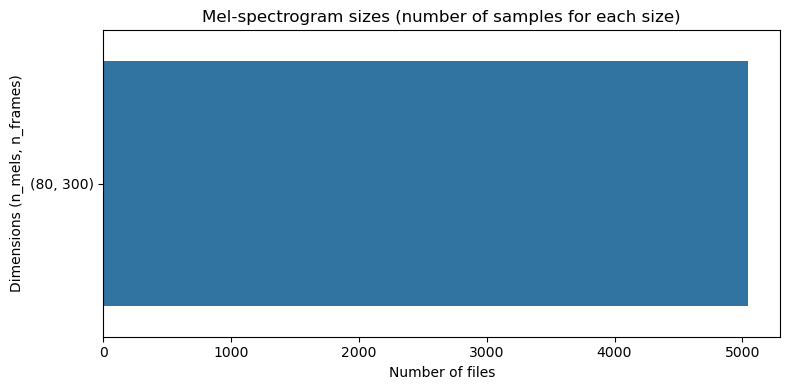

In [11]:
# Size distribution plot
df_mel["shape"] = df_mel.apply(lambda r: f"({r.n_mels}, {r.n_frames})", axis=1)

plt.figure(figsize=(8, 4))
sns.countplot(y="shape", data=df_mel, order=df_mel["shape"].value_counts().index)
plt.title("Mel-spectrogram sizes (number of samples for each size)")
plt.xlabel("Number of files")
plt.ylabel("Dimensions (n_mels, n_frames)")
plt.tight_layout()
plt.show()

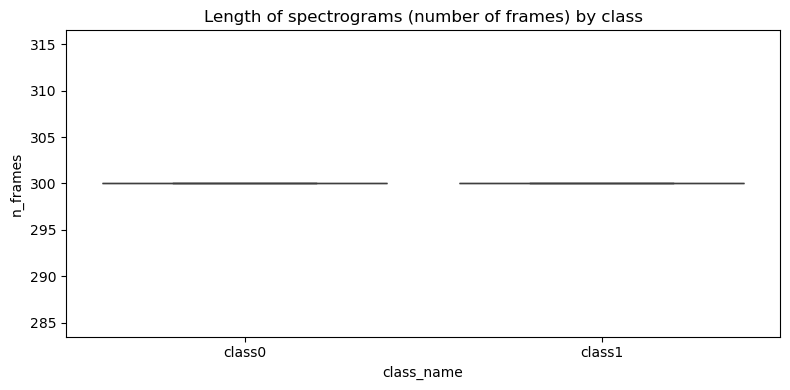

In [13]:
# Boxplot of n_frames by class
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_mel, x="class_name", y="n_frames")
plt.title("Length of spectrograms (number of frames) by class")
plt.ylabel("n_frames")
plt.xlabel("class_name")
plt.tight_layout()
plt.show()

All mel-spectrograms have consistent dimensions (80 mel bands, 300 frames).

In [14]:
# Statistical summary by class
stats = df_mel.groupby("class_name")[["mean", "std"]].describe().round(4)
display(stats)

mean                                                          \
             count    mean     std     min     25%     50%     75%     max   
class_name                                                                   
class0      2626.0 -0.0001  0.0017 -0.0045 -0.0013 -0.0001  0.0011  0.0076   
class1      2417.0 -0.0001  0.0018 -0.0052 -0.0015 -0.0002  0.0010  0.0096   

               std                                                          
             count    mean     std     min     25%     50%     75%     max  
class_name                                                                  
class0      2626.0  1.0002  0.0007  0.9924  0.9999  1.0004  1.0007  1.0015  
class1      2417.0  1.0003  0.0008  0.9877  0.9999  1.0004  1.0007  1.0015

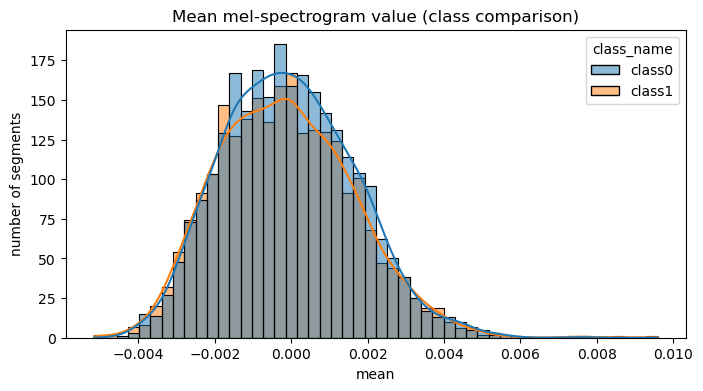

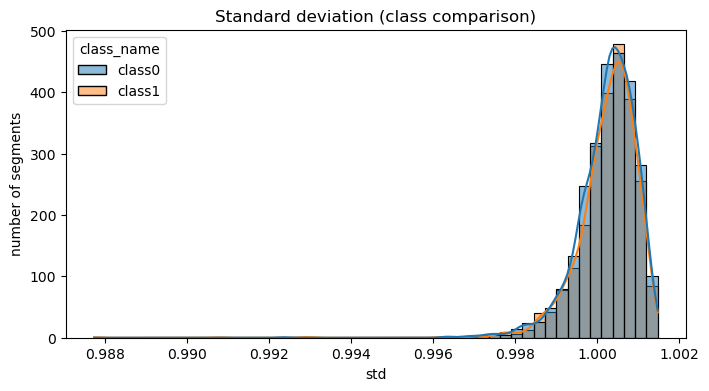

In [15]:
# Histograms of mean and std by class
plt.figure(figsize=(8, 4))
sns.histplot(df_mel, x="mean", hue="class_name", bins=50, kde=True)
plt.title("Mean mel-spectrogram value (class comparison)")
plt.xlabel("mean")
plt.ylabel("number of segments")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_mel, x="std", hue="class_name", bins=50, kde=True)
plt.title("Standard deviation (class comparison)")
plt.xlabel("std")
plt.ylabel("number of segments")
plt.show()

Mean and standard deviation values are similar across classes, with slight variations. <br>
The mean of the means is approximately 0, and the mean of the standard deviations is approximately 1.


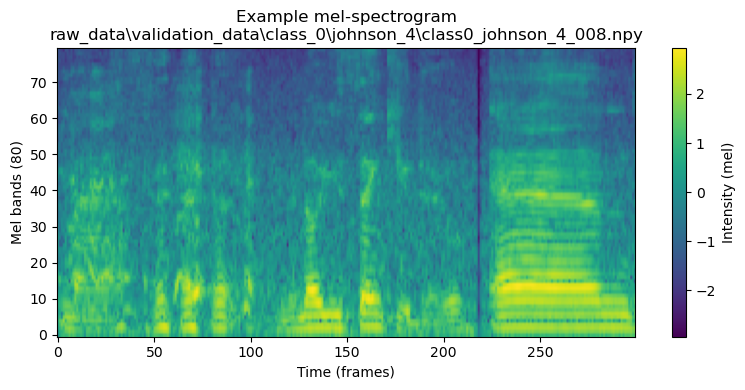

In [16]:
# Example mel-spectrogram visualization
example_path = df_mel.sample(1)["path"].iloc[0]
example = np.load(example_path)

plt.figure(figsize=(8, 4))
plt.imshow(example, aspect="auto", origin="lower")
plt.colorbar(label="Intensity (mel)")
plt.title(f"Example mel-spectrogram\n{example_path}")
plt.xlabel("Time (frames)")
plt.ylabel("Mel bands (80)")
plt.tight_layout()
plt.show()

In [17]:
# Histogram of mean energy over mel-bands and n_frames
def collect_histogram_data(df):
    mel_bands_means_class0 = []
    mel_bands_means_class1 = []
    time_means_class0 = []
    time_means_class1 = []

    for _, row in df.iterrows():
        mel = np.load(row["path"])

        mel_means = np.mean(mel, axis=1) 
        time_means = np.mean(mel, axis=0) 

        if row["class_number"] == 0:
            mel_bands_means_class0.append(mel_means)
            time_means_class0.append(time_means)
        else:
            mel_bands_means_class1.append(mel_means)
            time_means_class1.append(time_means)

    return {
        "mel_0": np.array(mel_bands_means_class0),
        "mel_1": np.array(mel_bands_means_class1),
        "time_0": np.array(time_means_class0),
        "time_1": np.array(time_means_class1)
    }

hist_data = collect_histogram_data(df_mel)

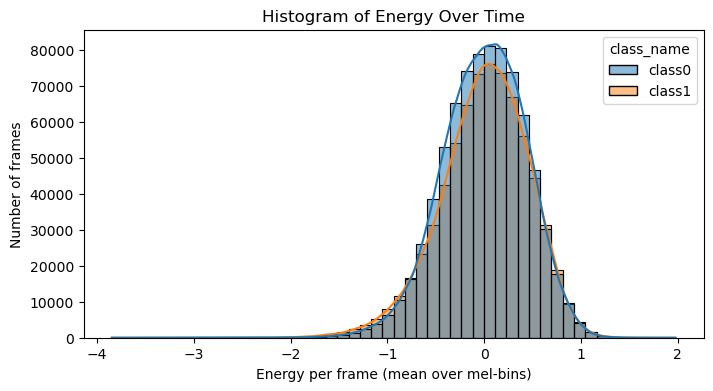

In [18]:
all_time_0 = hist_data["time_0"].flatten()
all_time_1 = hist_data["time_1"].flatten()

time_df = pd.DataFrame({
    "energy": np.concatenate([all_time_0, all_time_1]),
    "class_name": ["class0"] * len(all_time_0) + ["class1"] * len(all_time_1)
})

plt.figure(figsize=(8, 4))
sns.histplot(data=time_df, x="energy", hue="class_name",
             bins=50, kde=True, stat="count", common_norm=False)
plt.title("Histogram of Energy Over Time")
plt.xlabel("Energy per frame (mean over mel-bins)")
plt.ylabel("Number of frames")
plt.show()

The histogram reveals that the energy per frame distribution for both Class 0 and Class 1 is nearly identical and strongly overlapping. <br>
Class 0 has a greater total number of frames as its bars consistently exceed Class 1's bars in height.

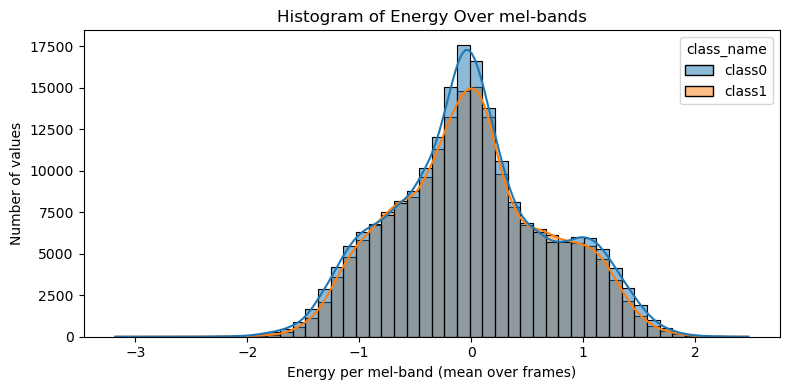

In [23]:

all_mel_0 = hist_data["mel_0"].flatten()
all_mel_1 = hist_data["mel_1"].flatten()

mel_df = pd.DataFrame({
    "energy": np.concatenate([all_mel_0, all_mel_1]),
    "class_name": ["class0"] * len(all_mel_0) + ["class1"] * len(all_mel_1)
})

plt.figure(figsize=(8, 4))
sns.histplot(data=mel_df, x="energy", hue="class_name",
             bins=50, kde=True, stat="count", common_norm=False)
plt.title("Histogram of Energy Over mel-bands")
plt.xlabel("Energy per mel-band (mean over frames)")
plt.ylabel("Number of values")

plt.tight_layout()
plt.show()

The histogram shows that the energy distribution is bimodal (two-peaked) for both classes, indicating the presence of two distinct dominant energy states in the audio data. <br>
These peaks occur near -0.1 (representing samples with lower average energy, such as quiet background or pauses) and near 1.0 (representing samples with higher average energy, such as active speech or louder sounds).

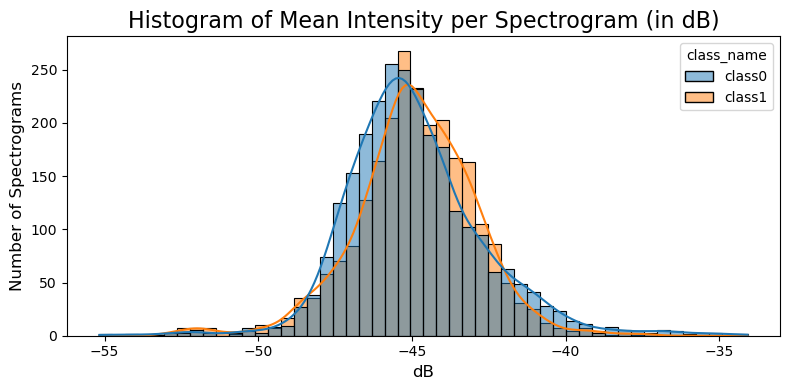

In [21]:
# Histogram of mean intensity per spectrogram (in dB)
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df_mel,
    x="mean_intensity_db",
    hue="class_name",
    bins=50,
    kde=True
)

plt.title("Histogram of Mean Intensity per Spectrogram (in dB)", fontsize=16)
plt.xlabel("dB", fontsize=12)
plt.ylabel("Number of Spectrograms", fontsize=12)

plt.tight_layout()
plt.show()

Mean intensity for Class 1 is slightly higher than for Class 0, as its distribution is shifted marginally to the right (towards higher dB values), although both distributions overlap significantly.